<a href="https://colab.research.google.com/github/jayu-cyber66/Text-Analytics/blob/main/Final_Text_Analytics68.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study 2: Text Analytics

<div align="center">
<img src="https://www.yelpblog.com/wp-content/uploads/2014/02/6a00d83452b44469e201a73d74acf8970d.png" width="1500" />
</div>

ชื่อกลุ่ม: F4


ชื่อ
นายจิรายุ สุโทวา  663020259-9

กำหนดส่ง: จันทร์ 9 กุมภาพันธ์ 2569 \
รายงานในชั้นเรียน: อังคาร 10 กุมภาพันธ์ 2569

**ผลที่คาดหวังจากการทำงานนี้**
* สามารถใช้ Python ในการอ่านข้อมูล
* จัดการกับข้อมูลเบื้องต้นในรูปแบบข้อความก่อนนำไปวิเคราะห์
* สามารถวิเคราะห์ข้อมูลตัวอักษรเบื้องต้นและสร้าง Data Visualization ที่เหมาะสมได้
----------------------

In [ ]:
"""
หากไม่สามารถลง library ใด ให้ดาวน์โหลดดังตัวอย่างต่อไปนี้
!pip install nltk
!pip install wordcloud
!pip install Pillow
"""
# Load these libraries
import json
import pprint
import pandas as pd
import numpy as np
from io import StringIO # using StringIO to prevent ValueError
from os import path
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import nltk
import urllib.request

import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from nltk.stem import PorterStemmer

In [ ]:
from google.colab import drive # เชื่อม google drive
drive.mount('/content/drive')

Mounted at /content/drive


## Problem 1: Working with Twitter Data and JSON file
*หมายเหตุ: ไม่ต้องนำเสนอข้อนี้*

จากข้อมูลทวิตเตอร์เกี่ยวกับประเทศไทยที่เก็บในวันที่ 31 สิงหาคม 2565 ในรูปแบบ JSON จาก `thailand_tweets.txt` ซึ่งมีการดึงข้อมูลมาด้วยคีเวิร์ด "Thailand" ให้ทำการศึกษาข้อมูลและดึงค่าจากข้อมูล \
ทั้งนี้เราสามารถเรียกหน้าทวีตจาก tweet ID ได้ดังนี้
```
twitter.com/anyuser/status/<tweet_id>
```


#### Read JSON file

In [ ]:
thailand_tweets = open('/content/drive/MyDrive/thailand_tweets.txt')
thailand_tweets = thailand_tweets.read()
jason_thailand_tweets = json.loads(thailand_tweets)
jason_thailand_tweets

'{"1564764893038882816": {"tweet_id": "1564764893038882816", "username": "matthunter", "name": "MATT HUNT\\u039eR", "profile_picture": "https://twitter.com/matthunter/photo", "replies": 2, "retweets": 1, "likes": 7, "is_retweet": false, "posted_time": "2022-08-30T23:59:57+00:00", "content": "Thanks for asking! Yes, we will support shipping to most countries, including Japan and Thailand. ", "hashtags": [], "mentions": [], "images": [], "videos": [], "tweet_url": "https://twitter.com/matthunter/status/1564764893038882816", "link": ""}, "1564764866598080513": {"tweet_id": "1564764866598080513", "username": "DavSmithVP", "name": "DavSmith / Virtual Photography", "profile_picture": "https://twitter.com/DavSmithVP/photo", "replies": 0, "retweets": 0, "likes": 2, "is_retweet": false, "posted_time": "2022-08-30T23:59:50+00:00", "content": "Tomb Raider Underworld | Thailand \\n#VirtualPhotography \\n@tombraider\\n @crystaldynamics", "hashtags": ["VirtualPhotography"], "mentions": ["tombraider"

In [ ]:
Th_JSON = json.loads(jason_thailand_tweets)
Th_JSON

{'1564764893038882816': {'tweet_id': '1564764893038882816',
  'username': 'matthunter',
  'name': 'MATT HUNTΞR',
  'profile_picture': 'https://twitter.com/matthunter/photo',
  'replies': 2,
  'retweets': 1,
  'likes': 7,
  'is_retweet': False,
  'posted_time': '2022-08-30T23:59:57+00:00',
  'content': 'Thanks for asking! Yes, we will support shipping to most countries, including Japan and Thailand. ',
  'hashtags': [],
  'mentions': [],
  'images': [],
  'videos': [],
  'tweet_url': 'https://twitter.com/matthunter/status/1564764893038882816',
  'link': ''},
 '1564764866598080513': {'tweet_id': '1564764866598080513',
  'username': 'DavSmithVP',
  'name': 'DavSmith / Virtual Photography',
  'profile_picture': 'https://twitter.com/DavSmithVP/photo',
  'replies': 0,
  'retweets': 0,
  'likes': 2,
  'is_retweet': False,
  'posted_time': '2022-08-30T23:59:50+00:00',
  'content': 'Tomb Raider Underworld | Thailand \n#VirtualPhotography \n@tombraider\n @crystaldynamics',
  'hashtags': ['Virtua

In [ ]:
Th_JSON.keys()

dict_keys(['1564764893038882816', '1564764866598080513', '1564764845685280772', '1564764710804897792', '1564764468277612549', '1564764445825458181', '1564764361742110720', '1564764274098323456', '1564764028014313472', '1564763907700531202', '1564763775403712513', '1564763746463105026', '1564763729967054848', '1564763679232405504', '1564763673662464003', '1564763553130655744', '1564763407818952705', '1564763389058027521', '1564763303989366784', '1564763292354355200', '1564763185244426240', '1564763141589897217', '1564763050477244417', '1564762341324992513', '1564762335192940544', '1564762170277052418', '1564762027507458049', '1564761944061382656', '1564761905410875392'])

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

tokens = nltk.word_tokenize(" ".join(Th_JSON[k]['content'] for k in Th_JSON))
contents_text = " ".join(PorterStemmer().stem(t) for t in tokens)
print(contents_text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


thank for ask ! ye , we will support ship to most countri , includ japan and thailand . tomb raider underworld | thailand # virtualphotographi @ tombraid @ crystaldynam the latest the pattaya daili ! http : //thepattayadaily.com thank to @ popekael @ aseannowth # thailand # pattaya you can live some place for next to noth , believ it or not . i pay $ 300 a month for a realli nice apart in thailand . all util includ . no deposit . close to the beach . live music club everywher . meal are about $ 2 alien hous is a stori of love , hope and alien intervent set in wale , thailand and inner space . it 's a # fantasi stori about # extraterrestri contact and the conflict between a man and hi inner voic or alter ego . william is not sure if he 's go mad http : //smarturl.it/alien-house-eng ? iqid=jbmegan… trend twitter updat top twitter influenc in thailand today # 4 @ ohmpawatt influenc score : 19442 7 top tweet 25182 retweet http : //etrenders.com/trendsetters/thailand… # ohmpawat # ยิ้ม5พันข

[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


#### Inspect data in JSON format (either reading using pretty print or Pandas data frame)

In [ ]:
# ----------------- Your code here -----------------
TH_JSON= json.dumps(Th_JSON, indent=4)
Th_JSON
pprint.pprint(Th_JSON)

{'1564761905410875392': {'content': 'Tinggal cari duitnya aja ini mah kalo di '
                                    'Thailand bisa pake Qris',
                         'hashtags': [],
                         'images': [],
                         'is_retweet': False,
                         'likes': 0,
                         'link': '',
                         'mentions': [],
                         'name': '',
                         'posted_time': '2022-08-30T23:48:04+00:00',
                         'profile_picture': 'https://twitter.com/moanfIeur/photo',
                         'replies': 0,
                         'retweets': 0,
                         'tweet_id': '1564761905410875392',
                         'tweet_url': 'https://twitter.com/moanfIeur/status/1564761905410875392',
                         'username': 'moanfIeur',
                         'videos': []},
 '1564761944061382656': {'content': 'Padahal berharap pertama lawan Thailand '
                     

In [ ]:
type(Th_JSON)

dict

#### Report: จงตอบคำถามต่อไปนี้
* The total number of tweets collected in the file
* The content of the first tweet:
* Is the first tweet contained any hashtags or mentions?
* Collect all hashtags related to Thailand from this data
* Find the most popular tweets in your collection of tweets, i.e. the tweets with the largest number of retweet/replies/likes counts  
* Display the top 5 tweets that are the most popular among your collection \
สามารถใช้ `np.argsort(<list>)[:5]` ซึ่งจะแสดงผล indices ของการเรียงค่าจากน้อยสุดไปมากสุด จำนวน 5 ค่า และ `np.argsort(<list>)[::-1][:5]` จะแสดงผล indices ของการเรียงค่าจากมากไปน้อยจำนวน 5 ค่า (https://numpy.org/doc/stable/reference/generated/numpy.argsort.html)
* Create a word cloud of words in the contents; however, we note that this word cloud is not a good representation of Thailand as the data size is small

# ข้อ1

In [ ]:
# 1 The total number of tweets collected in the file
len(Th_JSON)
print(f'จำนวน Tweet ทั้งหมดที่ถูกเก็บไว้ในไฟล์คือ : {len(Th_JSON)}')

จำนวน Tweet ทั้งหมดที่ถูกเก็บไว้ในไฟล์คือ : 29


# ข้อ2

In [ ]:
#2 The content of the first tweet:
first_key = list(Th_JSON)[0]
Th_JSON[first_key]
first_content = Th_JSON[first_key]['content']
first_content

'Thanks for asking! Yes, we will support shipping to most countries, including Japan and Thailand. '

# ข้อ3

In [ ]:
#3 Is the first tweet contained any hashtags or mentions?
hashtags = Th_JSON[first_key]['hashtags']
mentions = Th_JSON[first_key]['mentions']
print(f'Hashtags: {hashtags}')
print(f'Mentions: {mentions}')

Hashtags: []
Mentions: []


ทวีตแรก ไม่มี Hashtags เลย

ทวีตแรก ไม่มี Mentions (@ชื่อคน) เลย



# ข้อ4

In [ ]:
#4 Collect all hashtags related to Thailand from this data
from io import StringIO
tweet_data = pd.read_json(StringIO(json.dumps(Th_JSON)), orient='index')
tweet_data


,tweet_id,username,name,profile_picture,replies,retweets,likes,is_retweet,posted_time,content,hashtags,mentions,images,videos,tweet_url,link
2019-08-02 16:54:53.038882816,1564764893038882816,matthunter,MATT HUNTΞR,https://twitter.com/matthunter/photo,2,1,7,False,2022-08-30 23:59:57+00:00,"Thanks for asking! Yes, we will support shippi...",[],[],[],[],https://twitter.com/matthunter/status/15647648...,
2019-08-02 16:54:26.598080513,1564764866598080512,DavSmithVP,DavSmith / Virtual Photography,https://twitter.com/DavSmithVP/photo,0,0,2,False,2022-08-30 23:59:50+00:00,Tomb Raider Underworld | Thailand \n#VirtualPh...,[VirtualPhotography],"[tombraider, crystaldynamics]",[https://pbs.twimg.com/media/FbcpF-FXkAIlqTS?f...,[],https://twitter.com/DavSmithVP/status/15647648...,
2019-08-02 16:54:05.685280772,1564764845685280768,DailyPattaya,The Pattaya Daily,https://twitter.com/DailyPattaya/photo,0,0,0,False,2022-08-30 23:59:45+00:00,The latest The Pattaya Daily! http://thepattay...,"[thailand, pattaya]","[PopeKael, ASEANNOWTH]",[],[],https://twitter.com/DailyPattaya/status/156476...,
2019-08-02 16:51:50.804897792,1564764710804897792,Bryan62766077,Bryan,https://twitter.com/Bryan62766077/photo,1,0,1,False,2022-08-30 23:59:13+00:00,"You can live some places for next to nothing, ...",[],[],[],[],https://twitter.com/Bryan62766077/status/15647...,
2019-08-02 16:47:48.277612549,1564764468277612544,Megan_and_Grrr,Megan,https://twitter.com/Megan_and_Grrr/photo,0,0,0,False,2022-08-30 23:58:15+00:00,"ALIEN HOUSE is a story of love, hope and alien...","[fantasy, extraterrestrial]",[],[https://pbs.twimg.com/media/Fbco_bSXEAMcDOZ?f...,[],https://twitter.com/Megan_and_Grrr/status/1564...,
2019-08-02 16:47:25.825458181,1564764445825458176,OhmPawatInter,OhmPawat International,https://twitter.com/OhmPawatInter/photo,0,99,143,False,2022-08-30 23:58:10+00:00,Trend twitter update \n\nTop Twitter influence...,"[4, ohmpawat, ย]",[ohmpawatt],[https://pbs.twimg.com/media/Fbco99jWIAEd3Oe?f...,[],https://twitter.com/OhmPawatInter/status/15647...,
2019-08-02 16:46:01.742110720,1564764361742110720,nato_tonyo11,nutri(BUSY SI ENGR.)| SoliD,https://twitter.com/nato_tonyo11/photo,0,2,18,False,2022-08-30 23:57:50+00:00,Good morning world! And goodmorning to you to...,[DonnyPangilinan],[],[],[],https://twitter.com/nato_tonyo11/status/156476...,
2019-08-02 16:44:34.098323456,1564764274098323456,ThThitikarn61,thiti,https://twitter.com/ThThitikarn61/photo,0,0,0,False,2022-08-30 23:57:29+00:00,Listening to #faraway the title track of #theo...,"[faraway, theotherside, MarkTuan]",[marktuan],[],[],https://twitter.com/ThThitikarn61/status/15647...,
2019-08-02 16:40:28.014313472,1564764028014313472,Livetradingnews,Knightly News,https://twitter.com/Livetradingnews/photo,0,2,3,False,2022-08-30 23:56:30+00:00,With the recent news of the SCB X-Bitkub deal ...,[],[],[],[],https://twitter.com/Livetradingnews/status/156...,
2019-08-02 16:38:27.700531202,1564763907700531200,DiscoverSoc,Discover Society,https://twitter.com/DiscoverSoc/photo,0,1,0,False,2022-08-30 23:56:02+00:00,#ICYMI On the Frontline. Crude Power in Thail...,[ICYMI],[],[],[],https://twitter.com/DiscoverSoc/status/1564763...,https://t.co/OYQzv4BSm9


# ข้อ5

In [ ]:
#5 Find the most popular tweets in your collection of tweets, i.e. the tweets with the largest number of retweet/replies/likes counts
most_rt_key = max(Th_JSON, key=lambda k: Th_JSON[k]['retweets'])
most_rt_data = Th_JSON[most_rt_key]
most_rt_data

{'tweet_id': '1564764445825458181',
 'username': 'OhmPawatInter',
 'name': 'OhmPawat International',
 'profile_picture': 'https://twitter.com/OhmPawatInter/photo',
 'replies': 0,
 'retweets': 99,
 'likes': 143,
 'is_retweet': False,
 'posted_time': '2022-08-30T23:58:10+00:00',
 'content': 'Trend twitter update \n\nTop Twitter influencers in Thailand today \n#4 \n@ohmpawatt\nInfluence Score: 19442\n7 top tweets\n25182 retweets\n\nhttps://etrenders.com/trendsetters/Thailand…\n#ohmpawat #ยิ้ม5พันของโอมภวัต',
 'hashtags': ['4', 'ohmpawat', 'ย'],
 'mentions': ['ohmpawatt'],
 'images': ['https://pbs.twimg.com/media/Fbco99jWIAEd3Oe?format=jpg&name=small',
  'https://pbs.twimg.com/media/Fbco-JwWYAE7oLy?format=jpg&name=small'],
 'videos': [],
 'tweet_url': 'https://twitter.com/OhmPawatInter/status/1564764445825458181',
 'link': ''}

In [ ]:
most_rt_key = max(Th_JSON, key=lambda k: Th_JSON[k]['retweets'])
most_rt_data = Th_JSON[most_rt_key]

print("Tweet with the Most Retweets")
print("Tweet ID:", most_rt_key)
print("Username:", most_rt_data.get('username'))
print("Text:", most_rt_data.get('content'))
print("Name:", most_rt_data.get('name'))
print("Retweets:", most_rt_data.get('retweets'))
print("Replies:", most_rt_data.get('replies'))
print("Likes:", most_rt_data.get('likes'))


Tweet with the Most Retweets
Tweet ID: 1564764445825458181
Username: OhmPawatInter
Text: Trend twitter update 

Top Twitter influencers in Thailand today 
#4 
@ohmpawatt
Influence Score: 19442
7 top tweets
25182 retweets

https://etrenders.com/trendsetters/Thailand…
#ohmpawat #ยิ้ม5พันของโอมภวัต
Name: OhmPawat International
Retweets: 99
Replies: 0
Likes: 143


# ข้อ6

In [ ]:
# 6 Top5 Tweet
import numpy as np
scores = [Th_JSON[k]['retweets'] + Th_JSON[k]['likes'] + Th_JSON[k]['replies'] for k in Th_JSON]
top5 = np.argsort(scores)[::-1][:5]
keys = list(Th_JSON.keys())
for i in top5:
    t = Th_JSON[keys[i]]
    print(t['tweet_id'], t['username'], t['retweets'], t['likes'], t['replies'])


1564764445825458181 OhmPawatInter 99 143 0
1564762341324992513 Zeepruk_jfc 54 32 2
1564763729967054848 o_rung_o1 28 15 0
1564764361742110720 nato_tonyo11 2 18 0
1564763185244426240 Jay_beebee 7 7 1


In [ ]:
for tweet in top5:
    t = Th_JSON[keys[tweet]]
    print(t['tweet_id'], t['username'], t['retweets'], t['likes'], t['replies'])


1564764445825458181 OhmPawatInter 99 143 0
1564762341324992513 Zeepruk_jfc 54 32 2
1564763729967054848 o_rung_o1 28 15 0
1564764361742110720 nato_tonyo11 2 18 0
1564763185244426240 Jay_beebee 7 7 1


In [ ]:
top5_idx = np.argsort(scores)[::-1][:5]
top5_idx

array([ 5, 23, 12,  6, 20])

ทวีตอันดับ 1 อยู่ที่ index 5

ทวีตอันดับ 2 อยู่ที่ index 23

ทวีตอันดับ 3 อยู่ที่ index 12

ทวีตอันดับ 4 อยู่ที่ index 6

ทวีตอันดับ 5 อยู่ที่ index 20

In [ ]:
tweet_data.nlargest(5,'likes')

,tweet_id,username,name,profile_picture,replies,retweets,likes,is_retweet,posted_time,content,hashtags,mentions,images,videos,tweet_url,link
2019-08-02 16:47:25.825458181,1564764445825458176,OhmPawatInter,OhmPawat International,https://twitter.com/OhmPawatInter/photo,0,99,143,False,2022-08-30 23:58:10+00:00,Trend twitter update \n\nTop Twitter influence...,"[4, ohmpawat, ย]",[ohmpawatt],[https://pbs.twimg.com/media/Fbco99jWIAEd3Oe?f...,[],https://twitter.com/OhmPawatInter/status/15647...,
2019-08-02 16:12:21.324992513,1564762341324992512,Zeepruk_jfc,ZeePruk_JapanFC（Rest）,https://twitter.com/Zeepruk_jfc/photo,2,54,32,False,2022-08-30 23:49:48+00:00,Can you help me?\n\ntracking number\nFMP200001...,[Zunshine],[],[],[],https://twitter.com/Zeepruk_jfc/status/1564762...,
2019-08-02 16:46:01.742110720,1564764361742110720,nato_tonyo11,nutri(BUSY SI ENGR.)| SoliD,https://twitter.com/nato_tonyo11/photo,0,2,18,False,2022-08-30 23:57:50+00:00,Good morning world! And goodmorning to you to...,[DonnyPangilinan],[],[],[],https://twitter.com/nato_tonyo11/status/156476...,
2019-08-02 16:35:29.967054848,1564763729967054848,o_rung_o1,o_Rung_o,https://twitter.com/o_rung_o1/photo,0,28,15,False,2022-08-30 23:55:19+00:00,วันนี้วันสุดท้ายของการโหวต รางวัล Outstanding ...,"[SDA2022, voteforppkritt, ppkritt]",[],[https://pbs.twimg.com/media/FbcoUQAaQAAIFME?f...,[],https://twitter.com/o_rung_o1/status/156476372...,
2019-08-02 16:54:53.038882816,1564764893038882816,matthunter,MATT HUNTΞR,https://twitter.com/matthunter/photo,2,1,7,False,2022-08-30 23:59:57+00:00,"Thanks for asking! Yes, we will support shippi...",[],[],[],[],https://twitter.com/matthunter/status/15647648...,


# ข้อ7



In [ ]:
tokens = nltk.word_tokenize(" ".join(Th_JSON[k]['content'] for k in Th_JSON))
contents_text = " ".join(PorterStemmer().stem(t) for t in tokens)
print(contents_text)


thank for ask ! ye , we will support ship to most countri , includ japan and thailand . tomb raider underworld | thailand # virtualphotographi @ tombraid @ crystaldynam the latest the pattaya daili ! http : //thepattayadaily.com thank to @ popekael @ aseannowth # thailand # pattaya you can live some place for next to noth , believ it or not . i pay $ 300 a month for a realli nice apart in thailand . all util includ . no deposit . close to the beach . live music club everywher . meal are about $ 2 alien hous is a stori of love , hope and alien intervent set in wale , thailand and inner space . it 's a # fantasi stori about # extraterrestri contact and the conflict between a man and hi inner voic or alter ego . william is not sure if he 's go mad http : //smarturl.it/alien-house-eng ? iqid=jbmegan… trend twitter updat top twitter influenc in thailand today # 4 @ ohmpawatt influenc score : 19442 7 top tweet 25182 retweet http : //etrenders.com/trendsetters/thailand… # ohmpawat # ยิ้ม5พันข

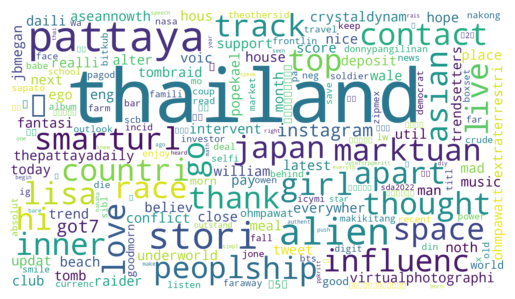

In [ ]:
#7 Create a word cloud of words in the contents; however, we note that this word cloud is not a good representation of Thailand as the data size is small

my_stopwords = set(STOPWORDS)
my_stopwords.update(["will","https","com","take","asking","p","S","twitter","yes","most","it","not","retweet","pleas","he","just","guy","from","is","set","or","like","send","cdnza","lek","di","iqid","@","#","more","in","?","me","help","number","doe","m","know","a","kalo","ye",".","$","are","about","an","sure","def","to","come","hi""วัล2ปี","$","/","//","+","=","ยิ้ม5พัน","ยิ้ม","พัน","วัล","ปี","Almost","Filipina", "Tinggal" ,"cari", "duitnya","ini", "mah", "kalo" ,"di","includ","ask",
"http",":","too","sure","cdn","etrenders","sjb","sibi"])

wordcloud = WordCloud(stopwords=my_stopwords, background_color="white", width=1920 , height=1080).generate(contents_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

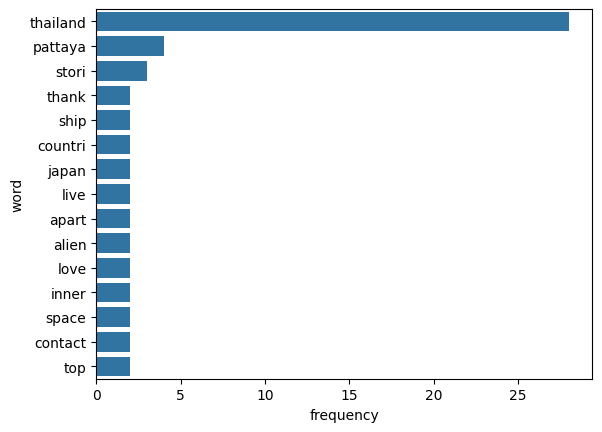

In [ ]:
from collections import Counter
import re, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

text = re.sub(r"http\S+|@\w+|#\w+|[^a-zA-Z\u0E00-\u0E7F\s]",
              "", contents_text.lower())

words = [w for w in text.split() if w not in my_stopwords and len(w) > 2]
word_freq = Counter(words)

df = pd.DataFrame(word_freq.most_common(15),
columns=["word", "frequency"])

sns.barplot(data=df, x="frequency", y="word")
plt.show()


## Problem 2: Study Collected Yelp Reviews

![](https://techcrunch.com/wp-content/uploads/2022/08/Yelp-Android_Full-Experience.jpg?w=1390&crop=1)

ดาวน์โหลด Yelp dataset เกี่ยวกับรีวิวของผู้ใช้บริการธุรกิจต่าง ๆ จาก https://www.yelp.com/dataset
<br>
รายละเอียดข้อมูล https://www.yelp.com/dataset/documentation/main
<br>
ให้ศึกษาข้อมูลจากไฟล์ yelp_academic_dataset_review.json, yelp_academic_dataset_business.json, และ yelp_academic_dataset_user.json

### อ่านข้อมูล Reviews, Businesses, และ Users เป็นจำนวน 100,000 รีวิว

In [ ]:
# เปลี่ยน path ของ working directory เช่น ที่ไหนใน Google Drive
myDirectory = "/content/drive/MyDrive/bebe/"
reviewFilePath = "yelp_academic_dataset_review.json"
businessFilePath = "yelp_academic_dataset_business.json"
userFilePath = "yelp_academic_dataset_user.json"

อ่านข้อมูล review

In [ ]:
# We only use the first 100,000 reviews
import json
import pandas as pd

n = 100000
reviews = []
with open('/content/drive/MyDrive/basic/yelp_academic_dataset_review.json') as fl:
    for i, line in enumerate(fl):
        reviews.append(json.loads(line))
        if i+1 >= n:
            break
reviews = pd.DataFrame(reviews)
reviews.head()

,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


In [ ]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   review_id    100000 non-null  object 
 1   user_id      100000 non-null  object 
 2   business_id  100000 non-null  object 
 3   stars        100000 non-null  float64
 4   useful       100000 non-null  int64  
 5   funny        100000 non-null  int64  
 6   cool         100000 non-null  int64  
 7   text         100000 non-null  object 
 8   date         100000 non-null  object 
dtypes: float64(1), int64(3), object(5)
memory usage: 6.9+ MB


อ่านข้อมูล business

In [ ]:
businesses = []
with open('/content/drive/MyDrive/basic/yelp_academic_dataset_business.json') as fl:
    for i, line in enumerate(fl):
        businesses.append(json.loads(line))
businesses = pd.DataFrame(businesses)
businesses.head()
businesses

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150341,IUQopTMmYQG-qRtBk-8QnA,Binh's Nails,3388 Gateway Blvd,Edmonton,AB,T6J 5H2,53.468419,-113.492054,3.0,13,1,"{'ByAppointmentOnly': 'False', 'RestaurantsPri...","Nail Salons, Beauty & Spas","{'Monday': '10:0-19:30', 'Tuesday': '10:0-19:3..."
150342,c8GjPIOTGVmIemT7j5_SyQ,Wild Birds Unlimited,2813 Bransford Ave,Nashville,TN,37204,36.115118,-86.766925,4.0,5,1,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Pets, Nurseries & Gardening, Pet Stores, Hobby...","{'Monday': '9:30-17:30', 'Tuesday': '9:30-17:3..."
150343,_QAMST-NrQobXduilWEqSw,Claire's Boutique,"6020 E 82nd St, Ste 46",Indianapolis,IN,46250,39.908707,-86.065088,3.5,8,1,"{'RestaurantsPriceRange2': '1', 'BusinessAccep...","Shopping, Jewelry, Piercing, Toy Stores, Beaut...",None
150344,mtGm22y5c2UHNXDFAjaPNw,Cyclery & Fitness Center,2472 Troy Rd,Edwardsville,IL,62025,38.782351,-89.950558,4.0,24,1,"{'BusinessParking': '{'garage': False, 'street...","Fitness/Exercise Equipment, Eyewear & Optician...","{'Monday': '9:0-20:0', 'Tuesday': '9:0-20:0', ..."


In [ ]:
businesses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150346 entries, 0 to 150345
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   business_id   150346 non-null  object 
 1   name          150346 non-null  object 
 2   address       150346 non-null  object 
 3   city          150346 non-null  object 
 4   state         150346 non-null  object 
 5   postal_code   150346 non-null  object 
 6   latitude      150346 non-null  float64
 7   longitude     150346 non-null  float64
 8   stars         150346 non-null  float64
 9   review_count  150346 non-null  int64  
 10  is_open       150346 non-null  int64  
 11  attributes    136602 non-null  object 
 12  categories    150243 non-null  object 
 13  hours         127123 non-null  object 
dtypes: float64(3), int64(2), object(9)
memory usage: 16.1+ MB


อ่านข้อมูล user

In [ ]:
users = []
with open('/content/drive/MyDrive/basic/yelp_academic_dataset_user.json') as fl:
    for i, line in enumerate(fl):
        users.append(json.loads(line))
users = pd.DataFrame(users)
users.head()

,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",267,...,65,55,56,18,232,844,467,467,239,180
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...","ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0A...",3138,...,264,184,157,251,1847,7054,3131,3131,1521,1946
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013","LuO3Bn4f3rlhyHIaNfTlnA, j9B4XdHUhDfTKVecyWQgyA...",52,...,13,10,17,3,66,96,119,119,35,18
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011","enx1vVPnfdNUdPho6PH_wg, 4wOcvMLtU6a9Lslggq74Vg...",28,...,4,1,6,2,12,16,26,26,10,9
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,,"PBK4q9KEEBHhFvSXCUirIw, 3FWPpM7KU1gXeOM_ZbYMbA...",1,...,1,0,0,0,1,1,0,0,0,0


In [ ]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1987897 entries, 0 to 1987896
Data columns (total 22 columns):
 #   Column              Dtype  
---  ------              -----  
 0   user_id             object 
 1   name                object 
 2   review_count        int64  
 3   yelping_since       object 
 4   useful              int64  
 5   funny               int64  
 6   cool                int64  
 7   elite               object 
 8   friends             object 
 9   fans                int64  
 10  average_stars       float64
 11  compliment_hot      int64  
 12  compliment_more     int64  
 13  compliment_profile  int64  
 14  compliment_cute     int64  
 15  compliment_list     int64  
 16  compliment_note     int64  
 17  compliment_plain    int64  
 18  compliment_cool     int64  
 19  compliment_funny    int64  
 20  compliment_writer   int64  
 21  compliment_photos   int64  
dtypes: float64(1), int64(16), object(5)
memory usage: 333.7+ MB


### รวมข้อมูล Reviews, Businesses, และ Users และสำรวจตัวแปรในข้อมูล

In [ ]:
# join reviews and businesses data using inner join
alldata = pd.merge(reviews, businesses, on='business_id', suffixes=('_review', '_business'))
# join reviews-businesses and users data using inner join
alldata = pd.merge(alldata, users, on='user_id', suffixes=('_review_business', '_user'))
alldata

,review_id,user_id,business_id,stars_review,useful_review_business,funny_review_business,cool_review_business,text,date,name_review_business,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11,Turning Point of North Wales,...,0,0,0,0,0,0,1,1,0,0
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18,Body Cycle Spinning Studio,...,0,0,0,0,0,0,0,0,0,0
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30,Kettle Restaurant,...,14,3,1,1,63,96,86,86,49,27
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03,Zaika,...,1,0,0,0,0,0,0,0,0,0
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15,Melt,...,0,0,0,0,0,1,0,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,pAEbIxvr6ebx2bHc1XvguA,SMH5CeiLvKx61lKwtLZ_PA,lV0k3BnslFRkuWD_kbKd0Q,4.0,0,0,0,Came here for lunch with a group. They were bu...,2018-05-30 22:28:56,Metro Diner,...,0,0,0,0,0,0,3,3,0,0
99996,xH1AoE-4nf2ECGQJRjO4_g,2clTdtp-BjphxLjN83CpUA,G0xz3kyRhRi6oZl7KfR0pA,1.0,1,0,0,The equipment is so old and so felty! I just u...,2015-04-05 23:31:52,Esporta Fitness,...,0,0,0,0,0,3,0,0,0,0
99997,GatIbXTz-WDru5emONUSIg,MRrN6DH3QGCFcDv5RENYVg,C4lZdhasjZVQyDlOiXY1sA,4.0,0,0,0,This is one of my favorite Mexican restaurants...,2016-06-04 00:59:15,Buena Vista Mexican Restaurant,...,0,0,0,0,1,1,0,0,0,0
99998,6NfkodAdhvI89xONXuBC3A,rnNQzeKJbvqVCsYsL10mkQ,dChRGpit9fM_kZK5pafNyA,2.0,0,0,0,Came here for brunch - had an omlette ($19 + t...,2018-06-11 12:45:08,The Love,...,1,0,0,0,5,1,1,1,0,0


In [ ]:
num_cols = alldata.select_dtypes(include=np.number).columns
num_cols

Index(['stars_review', 'useful_review_business', 'funny_review_business',
       'cool_review_business', 'latitude', 'longitude', 'stars_business',
       'review_count_review_business', 'is_open', 'review_count_user',
       'useful_user', 'funny_user', 'cool_user', 'fans', 'average_stars',
       'compliment_hot', 'compliment_more', 'compliment_profile',
       'compliment_cute', 'compliment_list', 'compliment_note',
       'compliment_plain', 'compliment_cool', 'compliment_funny',
       'compliment_writer', 'compliment_photos'],
      dtype='object')

### ทำการสำรวจข้อมูลเบื้องต้น

In [ ]:
alldata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 43 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   review_id                     100000 non-null  object 
 1   user_id                       100000 non-null  object 
 2   business_id                   100000 non-null  object 
 3   stars_review                  100000 non-null  float64
 4   useful_review_business        100000 non-null  int64  
 5   funny_review_business         100000 non-null  int64  
 6   cool_review_business          100000 non-null  int64  
 7   text                          100000 non-null  object 
 8   date                          100000 non-null  object 
 9   name_review_business          100000 non-null  object 
 10  address                       100000 non-null  object 
 11  city                          100000 non-null  object 
 12  state                         100000 non-null

In [ ]:
alldata.describe()


,stars_review,useful_review_business,funny_review_business,cool_review_business,latitude,longitude,stars_business,review_count_review_business,is_open,review_count_user,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.842910,0.898980,0.257180,0.347030,36.070867,-89.004401,3.77073,386.496810,0.765300,121.443680,...,1.989270,1.236880,0.781180,0.597050,11.662590,27.457690,21.278350,21.278350,8.735510,6.948680
std,1.354729,2.205186,1.010212,1.066382,5.297864,14.436547,0.67309,621.858339,0.423813,335.884257,...,25.633495,35.484054,14.809885,16.401987,93.670893,290.325764,199.736097,199.736097,88.572216,86.815935
min,1.000000,0.000000,0.000000,0.000000,27.555127,-120.095137,1.00000,5.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,0.000000,0.000000,0.000000,29.968642,-90.240317,3.50000,60.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.000000,0.000000,0.000000,0.000000,38.612945,-86.242167,4.00000,169.000000,1.000000,27.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.000000,1.000000,0.000000,0.000000,39.946685,-75.325628,4.00000,427.000000,1.000000,96.000000,...,1.000000,0.000000,0.000000,0.000000,3.000000,3.000000,2.000000,2.000000,2.000000,0.000000
max,5.000000,320.000000,98.000000,49.000000,53.644501,-74.658572,5.00000,4554.000000,1.000000,16567.000000,...,4347.000000,7039.000000,1622.000000,2607.000000,8616.000000,13807.000000,13280.000000,13280.000000,9821.000000,10346.000000


# ข้อมูลมีค่าว่าง (missing values) บ้างหรือไม่? หากมีให้ท่านอธิบายขั้นตอน และเหตุผลที่ใช้ในการจัดการกับค่าเหล่านี้

In [ ]:
alldata.isnull().sum()

,0
review_id,0
user_id,0
business_id,0
stars_review,0
useful_review_business,0
funny_review_business,0
cool_review_business,0
text,0
date,0
name_review_business,0


ข้อมูลมีค่าmissing คือ
attributes	1631 ค่า
categories	4 ค่า
hours	5824 ค่า

# จัดการค่า missimg

In [ ]:
alldata = alldata.fillna({'attributes': '{}','categories': 'Unknown','hours': '{}'})

In [ ]:
alldata.isnull().sum()

,0
review_id,0
user_id,0
business_id,0
stars_review,0
useful_review_business,0
funny_review_business,0
cool_review_business,0
text,0
date,0
name_review_business,0


สำรวจการแจกแจงของจำนวนรีวิวที่แต่ละ user ให้

In [ ]:
# ----------------- Your code here -----------------
counts = alldata['review_count_user']
print(counts.describe())
Q1, Q3 = counts.quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

outliers = counts[(counts < lower) | (counts > upper)]
print("\nOutliers:", len(outliers))


count    100000.000000
mean         65.513455
std          77.165020
min           1.000000
25%           9.000000
50%          27.000000
75%          96.000000
max         226.500000
Name: review_count_user, dtype: float64

Outliers: 0


In [ ]:
import warnings
warnings.filterwarnings('ignore')

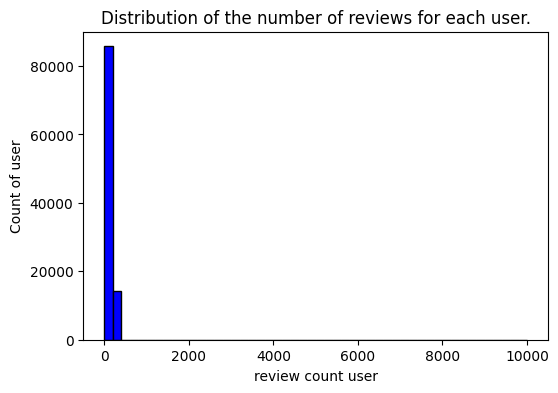

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.hist(alldata['review_count_user'],bins=50, range=(0, 10000), edgecolor='black', color='blue')
plt.xlabel('review count user')
plt.ylabel('Count of user')
plt.title('Distribution of the number of reviews for each user.')
plt.show()

ขยายกราฟข้างต้น

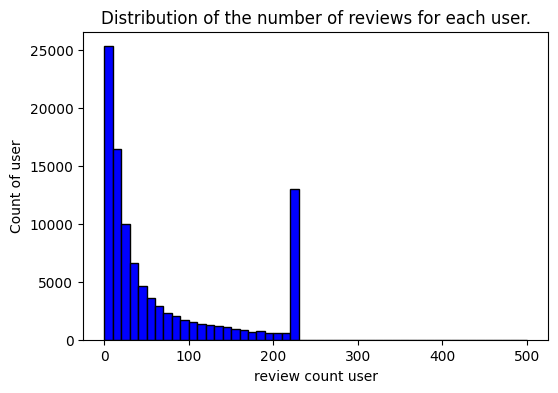

ผู้ใช้ส่วนใหญ่เขียนรีวิวน้อย (ไม่เกิน 20 รีวิว) ส่วนผู้ใช้ที่เขียนรีวิวจำนวนมากมีน้อยมาก ทำให้เกิดการกระจายแบบหางยาว (long-tail distribution) แสดงถึงความแตกต่างของพฤติกรรมผู้ใช้ในแพลตฟอร์มอย่างชัดเจน


In [ ]:
plt.figure(figsize=(6,4))
plt.hist(alldata['review_count_user'],bins=50, range=(0,500), edgecolor='black', color='blue')
plt.xlabel('review count user')
plt.ylabel('Count of user')
plt.title('Distribution of the number of reviews for each user.')
plt.show()

print(f"ผู้ใช้ส่วนใหญ่เขียนรีวิวน้อย (ไม่เกิน 20 รีวิว) ส่วนผู้ใช้ที่เขียนรีวิวจำนวนมากมีน้อยมาก ทำให้เกิดการกระจายแบบหางยาว (long-tail distribution) แสดงถึงความแตกต่างของพฤติกรรมผู้ใช้ในแพลตฟอร์มอย่างชัดเจน")

In [ ]:
counts_data = alldata['review_count_user']
print(counts.describe())

count    100000.000000
mean         65.513455
std          77.165020
min           1.000000
25%           9.000000
50%          27.000000
75%          96.000000
max         226.500000
Name: review_count_user, dtype: float64


In [ ]:
median_Des= alldata["review_count_user"].median()
print(f"Median : {median_Des}")


Median : 27.0


ข้อมูลจำนวนรีวิวของผู้ใช้ 100,000 คน พบว่าผู้ใช้ส่วนใหญ่เขียนรีวิวน้อย โดยค่ากลาง (Median) อยู่ที่เพียง 27 รีวิว ขณะที่ค่าเฉลี่ยสูงถึง 121 รีวิว เนื่องจากมีผู้ใช้บางคนเขียนรีวิวจำนวนมากจนดึงค่าเฉลี่ยขึ้น ส่วนเบี่ยงเบนมาตรฐานอยู่ที่ 335 แสดงถึงความกระจายตัวสูงมาก โดยค่าต่ำสุดคือ 1 รีวิว และค่าสูงสุดสูงถึง 16,567 รีวิว ทำให้ข้อมูลมีลักษณะเบ้ขวาอย่างชัดเจน

สำรวจการแจกแจงของจำนวนรีวิวและจำนวนดาวที่แต่ละ business ได้รับ

In [ ]:
# ----------------- Your code here -----------------


มีธุรกิจกี่แบบ และธุรกิจในแต่ละแบบมีจำนวนเท่าไหร่

* ลองแยก `categories` ออกเป็น category ย่อย แล้วสามารถนับหรือใช้ฟังก์ชัน Counter `from collections import Counter` ในการนับจำนวนหรือความถี่ของธุรกิจแต่ละแบบ \
ตัวอย่าง https://www.geeksforgeeks.org/counters-in-python-set-1/

In [ ]:
# ----------------- Your code here -----------------


### ให้ตั้งปัญหาหรือคำถาม และวิเคราะห์ข้อมูลเพื่อตอบคำถามดังกล่าว

<ระบุจุดประสงค์ของการศึกษา>

In [ ]:
# ----------------- Your code here -----------------


In [ ]:
#----------------------------------------------
# Your code starts here
# create some data visualization for the analysis and your presentation






## Problem 3: Retrieving Data from Internet

ให้แต่ละกลุ่มดึงข้อมูลเกี่ยวกับการเลือกตั้งที่จะถึงนี้ และทำการดึงข้อมูลที่เกี่ยวข้องผ่าน url ด้วยฟังก์ชัน `urllib.request.urlopen` จากแหล่งข้อมูลออนไลน์อย่างน้อย 10 แห่ง รวบรวมข้อมูลให้เป็นหนึ่งเดียว

In [ ]:
#----------------------------------------------
# Your code starts here


เตรียมข้อมูลและทำความสะอาดข้อมูลด้วยการทำ lower case, tokenization, removing stopwords (as well as punctuations, unrelated symbols, etc.), stemming, lemmatization เป็นต้น

In [ ]:
#----------------------------------------------
# Your code starts here


Text Mining: ทำการวิเคราะห์ข้อความที่รวบรวมมาได้ พร้อมทั้งแสดงการนำเสนอที่สร้างสรรค์

In [ ]:
#----------------------------------------------
# Your code starts here


-----------------
# เสร็จแล้ววววว 🥳

สิ่งที่ต้องแนบส่ง:
* Notebook File (ตัวอย่าง "filename.ipynb") หรือ Link to Google Colab ซึ่งมีผลลัพธ์จากการรันโค้ดแสดงทั้งหมด โดยไม่มี error และ**นำเสนอเฉพาะส่วนที่เกี่ยวข้องให้อาจารย์ดู** โดยทุกสิ่งที่ส่งมาจะนำมาประกอบการให้คะแนน
* Slides สำหรับการนำเสนอ **10** นาที ซึ่งประกอบไปด้วย
    * ตอบคำถามต่าง ๆ ใน Notebook
    * อธิบายวิธีการที่ใช้ และแสดง screenshots ของผลลัพธ์ที่ได้จาก Python Notebook โดยแสดงภาพและตาราง โดยไม่จำเป็นที่จะต้องนำเสนอ source code

** Note: แต่ละกลุ่มส่งแค่ครั้งเดียว **